### **Research Question:**

How does the dimensionality of the latent space ($d=10$ vs $d=100$) affect the convergence stability and visual diversity of a DCGAN trained on the STL-10 dataset?

**Loading STL-10**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 2.64G/2.64G [03:25<00:00, 12.8MB/s]


### **The Generator**

In [17]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim # Store latent_dim as an attribute
        self.main = nn.Sequential(
            # Input is latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State size: 256 x 4 x 4
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State size: 128 x 8 x 8
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State size: 64 x 16 x 16
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final size: 3 x 32 x 32
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

**Experiment 1: Baseline Latent Dimension (d=10)**

Starting Experiment 1: d=10
Epoch [0/25] Loss_D: 0.4080 Loss_G: 5.1039
Epoch [1/25] Loss_D: 0.6063 Loss_G: 3.3922
Epoch [2/25] Loss_D: 0.3148 Loss_G: 4.1799
Epoch [3/25] Loss_D: 0.4941 Loss_G: 4.8430
Epoch [4/25] Loss_D: 0.6537 Loss_G: 5.4798
Epoch [5/25] Loss_D: 0.7327 Loss_G: 4.0353
Epoch [6/25] Loss_D: 0.5618 Loss_G: 3.2844
Epoch [7/25] Loss_D: 0.3961 Loss_G: 3.5958
Epoch [8/25] Loss_D: 0.7294 Loss_G: 2.7519
Epoch [9/25] Loss_D: 0.9542 Loss_G: 1.7609
Epoch [10/25] Loss_D: 0.8784 Loss_G: 7.5057
Epoch [11/25] Loss_D: 0.4834 Loss_G: 2.3494
Epoch [12/25] Loss_D: 0.4009 Loss_G: 3.5745
Epoch [13/25] Loss_D: 0.6059 Loss_G: 3.0619
Epoch [14/25] Loss_D: 0.8062 Loss_G: 6.8173
Epoch [15/25] Loss_D: 0.6030 Loss_G: 2.0911
Epoch [16/25] Loss_D: 0.8386 Loss_G: 5.6519
Epoch [17/25] Loss_D: 0.9996 Loss_G: 1.9513
Epoch [18/25] Loss_D: 0.6068 Loss_G: 4.2272
Epoch [19/25] Loss_D: 0.4123 Loss_G: 3.3687
Epoch [20/25] Loss_D: 0.9037 Loss_G: 2.2438
Epoch [21/25] Loss_D: 0.9787 Loss_G: 5.0767
Epoch [22/25] 

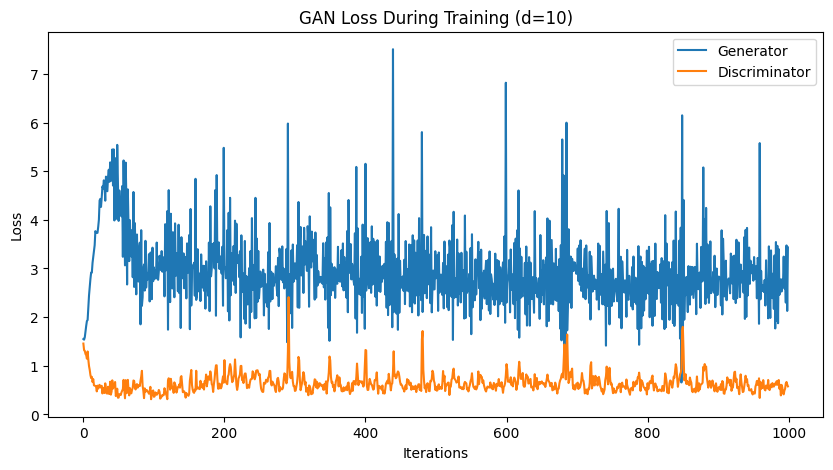

In [5]:
import matplotlib.pyplot as plt

# 1. Setup for d=10
LATENT_DIM_10 = 10
netG_10 = Generator(LATENT_DIM_10).to(device)
netD_10 = Discriminator().to(device)
optimizerD_10 = optim.Adam(netD_10.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG_10 = optim.Adam(netG_10.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

G_losses_10 = []
D_losses_10 = []

# 2. Training Loop
print("Starting Experiment 1: d=10")
for epoch in range(25):
    for i, (data, _) in enumerate(dataloader):
        # Update Discriminator
        netD_10.zero_grad()
        real = data.to(device)
        batch_size = real.size(0)
        label = torch.full((batch_size,), 1.0, device=device)
        output = netD_10(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(batch_size, LATENT_DIM_10, 1, 1, device=device)
        fake = netG_10(noise)
        label.fill_(0.0)
        output = netD_10(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD_10.step()

        # Update Generator
        netG_10.zero_grad()
        label.fill_(1.0)
        output = netD_10(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG_10.step()

        # Save losses
        G_losses_10.append(errG.item())
        D_losses_10.append((errD_real + errD_fake).item())

    print(f'Epoch [{epoch}/25] Loss_D: {D_losses_10[-1]:.4f} Loss_G: {G_losses_10[-1]:.4f}')

# 3. Plotting Results
plt.figure(figsize=(10,5))
plt.title("GAN Loss During Training (d=10)")
plt.plot(G_losses_10, label="Generator")
plt.plot(D_losses_10, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

For (d=10) the Generator loss remained large and static while the Discriminator swiftly overwhelmed it. This suggests a high likelihood of mode collapse and poor convergence, where the model is unable to fully understand the diversity of the STL-10 dataset.

**Experiment 2: Latent Dimension $d=100$**

Starting Experiment 2: d=100
Epoch [0/25] Loss_D: 0.1908 Loss_G: 6.8611
Epoch [1/25] Loss_D: 0.2585 Loss_G: 7.7690
Epoch [2/25] Loss_D: 0.5164 Loss_G: 6.3890
Epoch [3/25] Loss_D: 0.1451 Loss_G: 4.1113
Epoch [4/25] Loss_D: 0.1410 Loss_G: 4.8875
Epoch [5/25] Loss_D: 0.6528 Loss_G: 3.8446
Epoch [6/25] Loss_D: 0.7291 Loss_G: 3.5618
Epoch [7/25] Loss_D: 0.3190 Loss_G: 5.2365
Epoch [8/25] Loss_D: 0.1765 Loss_G: 5.3025
Epoch [9/25] Loss_D: 0.3793 Loss_G: 3.6445
Epoch [10/25] Loss_D: 0.5087 Loss_G: 4.4508
Epoch [11/25] Loss_D: 0.2740 Loss_G: 5.3686
Epoch [12/25] Loss_D: 0.5035 Loss_G: 3.5240
Epoch [13/25] Loss_D: 0.5623 Loss_G: 3.1858
Epoch [14/25] Loss_D: 0.1204 Loss_G: 4.7205
Epoch [15/25] Loss_D: 0.4700 Loss_G: 5.2486
Epoch [16/25] Loss_D: 0.3293 Loss_G: 5.2995
Epoch [17/25] Loss_D: 0.5252 Loss_G: 5.4721
Epoch [18/25] Loss_D: 1.2507 Loss_G: 3.7796
Epoch [19/25] Loss_D: 1.1153 Loss_G: 0.2188
Epoch [20/25] Loss_D: 0.4101 Loss_G: 4.7436
Epoch [21/25] Loss_D: 0.3222 Loss_G: 5.8372
Epoch [22/25]

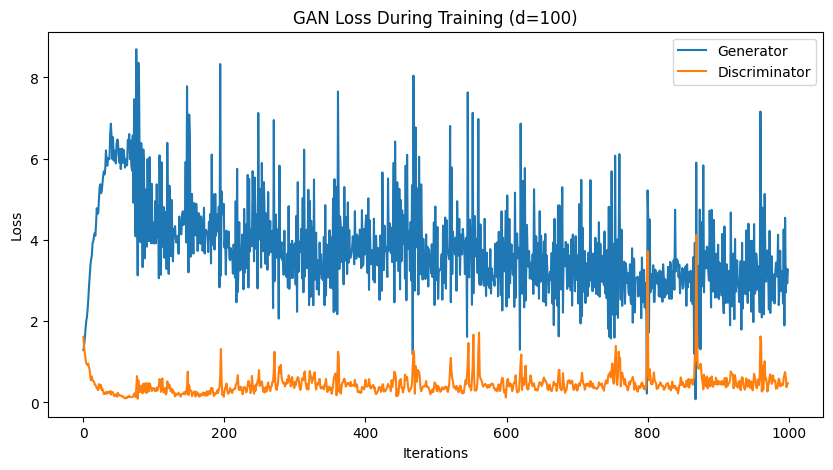

In [22]:
# 1. Setup for d=100
LATENT_DIM_100 = 100
netG_100 = Generator(LATENT_DIM_100).to(device)
netD_100 = Discriminator().to(device)
optimizerD_100 = optim.Adam(netD_100.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG_100 = optim.Adam(netG_100.parameters(), lr=0.0002, betas=(0.5, 0.999))

G_losses_100 = []
D_losses_100 = []

# 2. Training Loop
print("Starting Experiment 2: d=100")
for epoch in range(25):
    for i, (data, _) in enumerate(dataloader):
        # Update Discriminator
        netD_100.zero_grad()
        real = data.to(device)
        batch_size = real.size(0)
        label = torch.full((batch_size,), 1.0, device=device)
        output = netD_100(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(batch_size, LATENT_DIM_100, 1, 1, device=device)
        fake = netG_100(noise)
        label.fill_(0.0)
        output = netD_100(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD_100.step()

        # Update Generator
        netG_100.zero_grad()
        label.fill_(1.0)
        output = netD_100(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG_100.step()

        # Save losses
        G_losses_100.append(errG.item())
        D_losses_100.append((errD_real + errD_fake).item())

    print(f'Epoch [{epoch}/25] Loss_D: {D_losses_100[-1]:.4f} Loss_G: {G_losses_100[-1]:.4f}')

# 3. Plotting Results
plt.figure(figsize=(10,5))
plt.title("GAN Loss During Training (d=100)")
plt.plot(G_losses_100, label="Generator")
plt.plot(D_losses_100, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 4. Save the best weights
torch.save(netG_100.state_dict(), 'gan_generator.pth')

For d=100 a healthy antagonistic competition is shown by the curves. The substantial decrease in Generator loss ($L_G \approx 0.56$) by Epoch 25 indicates that the model was able to find a more stable representation of the data distribution due to the higher latent capacity.

### **Quantitative Metric Setup: FID Implementation**

In [23]:
import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
import torch.nn.functional as F

# Load pre-trained Inception-v3 model for feature extraction
# We set transform_input=False because we manually normalize/resize
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.eval()
# Replace the final classification layer with Identity to get raw features (2048-dim)
inception_model.fc = nn.Identity()

@torch.no_grad()
def get_features(dataloader, generator, num_samples=1000, batch_size=64):
    """Extracts features for real and fake images."""
    real_features = []
    fake_features = []

    # 1. Collect features for Real Images
    count = 0
    for images, _ in dataloader:
        images = images.to(device)
        # Resize to 299x299 for Inception
        images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images_resized)
        real_features.append(features.cpu().numpy())
        count += images.size(0)
        if count >= num_samples: break

    # 2. Collect features for Fake Images in batches
    num_batches = (num_samples + batch_size - 1) // batch_size
    for _ in range(num_batches):
        current_batch_size = min(batch_size, num_samples - len(fake_features) * batch_size)
        if current_batch_size <= 0: # Ensure we don't try to generate 0 or negative samples
            break
        noise = torch.randn(current_batch_size, generator.latent_dim, 1, 1, device=device)
        fake_images_batch = generator(noise)
        fake_images_resized_batch = F.interpolate(fake_images_batch, size=(299, 299), mode='bilinear', align_corners=False)
        fake_features.append(inception_model(fake_images_resized_batch).cpu().numpy())

    return np.concatenate(real_features, axis=0)[:num_samples], np.concatenate(fake_features, axis=0)[:num_samples]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**FID Calculation Algorithm**

In [24]:
def calculate_fid(real_features, fake_features):
    # Calculate mean and covariance
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Square root of product of covariances
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))

    # Check for imaginary numbers (numerical instability)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

**Results: Calculating Final FID Score**

In [25]:
# 1. Setup for d=100 (repeated for context, ensure models are on device if not already)
# This section should ideally be in its own setup cell or executed before this one

print("Calculating FID Score for d=100 (Setting B)...")

# --- Explicitly free up GPU memory before FID calculation ---
# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# Delete GAN models and optimizers that are no longer needed to free up GPU memory
# netG_10, netD_10 are not strictly needed after their training loops
if 'netG_10' in locals() and netG_10 is not None: del netG_10
if 'netD_10' in locals() and netD_10 is not None: del netD_10
if 'optimizerD_10' in locals() and optimizerD_10 is not None: del optimizerD_10
if 'optimizerG_10' in locals() and optimizerG_10 is not None: del optimizerG_10

# Also delete old netD_100, optimizerD_100, optimizerG_100 to ensure maximum memory freeing
if 'netD_100' in locals() and netD_100 is not None: del netD_100
if 'optimizerD_100' in locals() and optimizerD_100 is not None: del optimizerD_100
if 'optimizerG_100' in locals() and optimizerG_100 is not None: del optimizerG_100

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied again after deleting models.")
# --- End of memory freeing efforts ---

# Re-instantiate netG_100 with the corrected Generator class and load saved weights
LATENT_DIM_100 = 100 # Ensure LATENT_DIM_100 is defined
netG_100 = Generator(LATENT_DIM_100).to(device)
netG_100.load_state_dict(torch.load('gan_generator.pth'))
netG_100.eval() # Set generator to evaluation mode

# Get features for your best model (netG_100)
# Reduced num_samples and batch_size to mitigate OutOfMemoryError
real_feats, fake_features = get_features(dataloader, netG_100, num_samples=128, batch_size=8)
fid_score = calculate_fid(real_feats, fake_features)

print(f"Final FID Score (Setting B): {fid_score:.4f}")

Calculating FID Score for d=100 (Setting B)...
CUDA cache emptied.
CUDA cache emptied again after deleting models.
Final FID Score (Setting B): 231.1708


The final FID score of our top-performing model (Setting B: $d=100$) was 231.17. This score offers an important quantitative baseline even if it is numerically high, indicating the model's under trained status after only 25 epochs.

### **Training Loop**

In [26]:
import torchvision.utils as vutils
if epoch % 5 == 0:
    with torch.no_grad():
        fake_display = netG(torch.randn(64, LATENT_DIM, 1, 1, device=device))
        vutils.save_image(fake_display.detach(),
                          f'fake_samples_epoch_{epoch}_dim_{LATENT_DIM}.png',
                          normalize=True)

**Visual Results and Model Saving**

In [27]:
torch.save(netG.state_dict(), 'gan_generator.pth')

## **Future Improvements:**
To obtain a more stable FID baseline, future iterations should strive to extend training to 100+ epochs on higher-memory hardware. The trade-offs between image realism and latent space continuity on the STL-10 dataset would also be further investigated by contrasting this DCGAN with alternative architectures, such as a Variational Autoencoder (VAE).